In [1]:
import pandas as pd
import numpy as np

In [2]:
slot_block = pd.read_csv('slot_block.csv')
slot_block

,slot,block
0,6732346,17549584.0
1,6737147,17554330.0
2,6738421,17555586.0
3,6725167,17542492.0
4,6733146,17550375.0
...,...,...
8992507,303065,NaN
8992508,311256,NaN
8992509,311243,NaN
8992510,303074,NaN


In [ ]:
metadata2 = pd.read_csv('../data/validator_metadata.csv')
metadata = pd.read_csv('../int/validator_metadata_v2.csv')
metadata = metadata.merge(metadata2[['validator_pubkey', 'validator_index']], on='validator_index', how='left')

metadata = metadata.sort_values(by='validator_index').reset_index(drop=True)

bins = [0, 2, 6, 20, 100, float('inf')]  # 'inf' represents infinity for the last bin

# Define the labels for each bin
labels = ['1', '2-5', '6-19', '20-99', '100+']

# Create a new column with labels based on 'pool_size'
metadata['pool_size_label'] = pd.cut(metadata['pool_size'], bins=bins, labels=labels, right=False)

metadata['category'] = metadata['category'].replace({'Solo Staker': 'Solo Stakers', 'Staking Pool': 'Staking Pools'})


metadata

In [4]:
pools = pd.read_csv('../data/pool_categories.csv')
pools

,pool,category
0,Poloniex,CEX
1,Cream Finance,Liquid Staking
2,Vitalik Buterin,Solo Stakers
3,Ankr,Liquid Staking
4,PieDAO,Staking Pools
5,Wexexchange,CEX
6,Bitpie,Staking Pools
7,Bitstamp,CEX
8,Liquid Collective,Liquid Staking
9,Huobi,CEX


In [5]:
depo = pd.read_csv('../data/deposits.csv')
depo = depo.sort_values(by='deposit_index').reset_index(drop=True)
depo = pd.merge(depo, slot_block, left_on='block_number', right_on='block', how='left')
depo = depo.drop(columns='block')
depo['amount'] = depo['amount'] / (10**9)
depo['amount_cum'] = depo['amount'].cumsum()

depo

,block_number,block_timestamp,deposit_index,validator_pubkey,amount,slot,amount_cum
0,11185311,2020-11-03 16:44:26 UTC,0,\\x933ad9491b62059dd065b560d256d8957a8c402cc6e...,1.0,NaN,1.0
1,11191448,2020-11-04 15:23:35 UTC,1,\\xa1d1ad0714035353258038e964ae9675dc0252ee22c...,1.0,NaN,2.0
2,11191495,2020-11-04 15:33:10 UTC,2,\\xb2ff4716ed345b05dd1dfc6a5a9fa70856d8c75dcc9...,1.0,NaN,3.0
3,11191501,2020-11-04 15:34:37 UTC,3,\\x8e323fd501233cd4d1b9d63d74076a38de50f2f584b...,1.0,NaN,4.0
4,11191512,2020-11-04 15:37:54 UTC,4,\\xa62420543ceef8d77e065c70da15f7b731e56db5457...,1.0,NaN,5.0
...,...,...,...,...,...,...,...
1461923,19782083,2024-05-02 11:16:47 UTC,1461959,\\x8e6cb2313ea3c5979f804e8c49a573c04c488ec0d07...,32.0,8985382.0,44263101.0
1461924,19782085,2024-05-02 11:17:11 UTC,1461960,\\xb6cd027b4f27aa941c47764edfb53a608364a4efcb9...,32.0,8985384.0,44263133.0
1461925,19782086,2024-05-02 11:17:23 UTC,1461961,\\x982f2550240e04244e6db250ad08207a5c41e2168ff...,32.0,8985385.0,44263165.0
1461926,19782088,2024-05-02 11:17:47 UTC,1461962,\\x95d0a7413578f75c9deb78b82ef03bd86f2c2dd4f16...,32.0,8985387.0,44263197.0


In [6]:
rewards = pd.read_csv('../data/validator_rewards.csv')
rewards = rewards.sort_values(by='consensus_slot').reset_index(drop=True)
rewards = pd.merge(rewards, metadata[['validator_index', 'category', 'pool', 'pool_size_label']], on='validator_index', how='left')
rewards.rename(columns={'consensus_slot': 'slot'}, inplace=True)

rewards['consensus_rewards'] = rewards['consensus_rewards'] / (10**8)
rewards['execution_rewards'] = rewards['execution_rewards'] / (10**9)
rewards['baseline_mev'] = rewards['baseline_mev'] / (10**9)
rewards['consensus+execution'] = rewards['consensus_rewards'] + rewards['execution_rewards']
rewards['consensus_cum'] = rewards['consensus_rewards'].cumsum()
rewards['consensus+execution_cum'] = rewards['consensus+execution'].cumsum()


rewards['pool_consensus_cum'] = rewards.groupby('pool')['consensus_rewards'].cumsum()
rewards['pool_rewards_cum'] = rewards.groupby('pool')['consensus+execution_cum'].cumsum()

rewards['category_consensus_cum'] = rewards.groupby('category')['consensus_rewards'].cumsum()
rewards['category_rewards_cum'] = rewards.groupby('category')['consensus+execution_cum'].cumsum()


rewards['size_consensus_cum'] = rewards.groupby('pool_size_label')['consensus_rewards'].cumsum()
rewards['size_rewards_cum'] = rewards.groupby('pool_size_label')['consensus+execution_cum'].cumsum()



rewards

,slot,validator_index,consensus_rewards,execution_rewards,baseline_mev,category,pool,pool_size_label,consensus+execution,consensus_cum,consensus+execution_cum,pool_consensus_cum,pool_rewards_cum,category_consensus_cum,category_rewards_cum,size_consensus_cum,size_rewards_cum
0,0,10453,0.000000,0.000000,0.000000,Unidentified,Unidentified,100+,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00
1,1,19026,0.000000,0.000000,0.000000,Unidentified,Unidentified,1,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00
2,2,11516,0.000000,0.000000,0.000000,CEX,Bitcoin Suisse,100+,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00
3,3,20640,0.000000,0.000000,0.000000,Unidentified,Unidentified,100+,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00
4,4,11308,0.000000,0.000000,0.000000,Unidentified,Unidentified,100+,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8986171,8986171,1149558,0.443984,0.018265,0.003758,Staking Pools,Ledger Live,100+,0.462248,2.096238e+06,2.572595e+06,13839.831541,6.799008e+10,93991.365941,3.157112e+11,1.889479e+06,6.493894e+12
8986172,8986172,939434,0.441031,0.020240,0.008199,CEX,Kraken,100+,0.461271,2.096238e+06,2.572596e+06,122871.533251,3.138139e+11,711091.489980,2.243384e+12,1.889480e+06,6.493897e+12
8986173,8986173,1175489,0.445289,0.022277,0.001970,Liquid Staking,Lido,100+,0.467566,2.096239e+06,2.572596e+06,624980.222626,2.225578e+12,705979.842163,2.535752e+12,1.889480e+06,6.493899e+12
8986174,8986174,398671,0.421257,0.009399,0.000000,Unidentified,Unidentified,20-99,0.430656,2.096239e+06,2.572597e+06,509171.843557,1.812977e+12,509171.843557,1.812977e+12,1.025844e+05,3.396685e+11


In [7]:
withdrawals = pd.read_csv('../data/withdrawals_slot_under_7m.csv')

withdrawals = pd.concat([withdrawals, pd.read_csv('../data/withdrawals_slot_over_7m.csv')])
withdrawals = withdrawals.sort_values(by='block_number').reset_index(drop=True)
withdrawals.rename(columns={'block_number': 'slot'}, inplace=True)
withdrawals = pd.merge(withdrawals, metadata[['validator_index', 'category', 'pool', 'pool_size_label']], on='validator_index', how='left')

withdrawals['amount'] = withdrawals['amount'] / (10**9)
withdrawals['amount_cum'] = withdrawals['amount'].cumsum()

withdrawals['pool_amount_cum'] = withdrawals.groupby('pool')['amount'].cumsum()

withdrawals['category_amount_cum'] = withdrawals.groupby('category')['amount'].cumsum()

withdrawals['size_amount_cum'] = withdrawals.groupby('pool_size_label')['amount'].cumsum()

withdrawals

,slot,validator_index,amount,category,pool,pool_size_label,amount_cum,pool_amount_cum,category_amount_cum,size_amount_cum
0,6209540,26591,4.547643,Unidentified,Unidentified,1,4.547643e+00,4.547643e+00,4.547643e+00,4.547643e+00
1,6209540,27573,4.440881,Unidentified,Unidentified,20-99,8.988524e+00,8.988524e+00,8.988524e+00,4.440881e+00
2,6209540,24862,4.451501,Unidentified,Unidentified,6-19,1.344002e+01,1.344002e+01,1.344002e+01,4.451501e+00
3,6209542,33898,4.480416,Solo Stakers,Daniel Wang,100+,1.792044e+01,4.480416e+00,4.480416e+00,4.480416e+00
4,6209542,39511,4.216908,Unidentified,Unidentified,2-5,2.213735e+01,1.765693e+01,1.765693e+01,4.216908e+00
...,...,...,...,...,...,...,...,...,...,...
43940710,8984512,1083236,0.018363,CEX,Coinbase,100+,1.368459e+07,2.508604e+06,5.836249e+06,1.271464e+07
43940711,8984512,1083230,0.018279,Unidentified,Unidentified,100+,1.368459e+07,3.967406e+06,3.967406e+06,1.271464e+07
43940712,8984512,1083235,0.018264,CEX,Coinbase,100+,1.368459e+07,2.508604e+06,5.836249e+06,1.271464e+07
43940713,8984512,1083234,0.018363,CEX,Coinbase,100+,1.368459e+07,2.508604e+06,5.836249e+06,1.271464e+07


In [8]:
min_withdrawals = withdrawals['slot'].min()
max_withdrawals = withdrawals['slot'].max()

min_rewards = rewards['slot'].min()
max_rewards = rewards['slot'].max()

min_depo = depo['slot'].min()
max_depo = depo['slot'].max()

min_slot = max(min_rewards, min_depo)
max_slot = min(max_withdrawals, max_rewards, max_depo)

print(min_depo)
print(min_rewards)
print(min_slot)
print(min_withdrawals)
print(max_slot)

4700213.0
0
4700213.0
6209540
8984512


In [ ]:
depo2 = depo[['slot', 'amount_cum']]
depo2.dropna(inplace=True)
depo2.drop_duplicates(subset=['slot'], inplace=True, keep='last')

withdrawals2 = withdrawals[['slot', 'amount_cum']]
withdrawals2.dropna(inplace=True)
withdrawals2.drop_duplicates(subset=['slot'], inplace=True, keep='last')

rewards2 = rewards[['slot', 'consensus_cum', 'consensus+execution_cum', 'pool_consensus_cum', 'pool_rewards_cum', 'category_consensus_cum', 'category_rewards_cum', 'size_consensus_cum', 'size_rewards_cum', 'consensus_rewards', 'consensus+execution', 'pool', 'category', 'pool_size_label']]
rewards2.dropna(inplace=True)
rewards2.drop_duplicates(subset=['slot'], inplace=True, keep='last')
rewards2 = rewards2[rewards2['slot'] >= 4700213]

staked = pd.merge(rewards2, depo2, on='slot', how='left')
staked = pd.merge(staked, withdrawals2, on='slot', how='left')
staked = staked[staked['slot'] <= 8984512]
staked.columns = ['slot', 'consensus_cum', 'consensus+execution_cum', 'pool_consensus_cum', 'pool_rewards_cum', 'category_consensus_cum', 'category_rewards_cum', 'size_consensus_cum', 'size_rewards_cum', 'consensus_rewards', 'consensus+execution', 'pool_rewards', 'category_rewards', 'pool_size_label_rewards', 'deposits', 'withdrawals']
staked.loc[0, 'withdrawals'] = 0
staked.fillna(method='ffill', inplace=True)
staked['staked eth'] = staked['consensus_cum'] + staked['deposits'] - staked['withdrawals']
staked['execution'] = staked['consensus+execution'] - staked['consensus_rewards']

staked

In [10]:
staked['rewards_ann'] = staked['consensus+execution'] * 365 * 24 * 60 * 60 / (12 * staked['staked eth'])
staked['consensus_ann'] = staked['consensus_rewards'] * 365 * 24 * 60 * 60 / (12 * staked['staked eth'])
staked['execution_ann'] = staked['execution'] * 365 * 24 * 60 * 60 / (12 * staked['staked eth'])

staked

,slot,consensus_cum,consensus+execution_cum,pool_consensus_cum,pool_rewards_cum,category_consensus_cum,category_rewards_cum,size_consensus_cum,size_rewards_cum,consensus_rewards,...,pool_rewards,category_rewards,pool_size_label_rewards,deposits,withdrawals,staked eth,execution,rewards_ann,consensus_ann,execution_ann
0,4700213,5.810196e+05,5.810993e+05,47646.066174,5.002577e+10,231178.700503,2.482971e+11,5.100557e+05,5.744042e+11,0.283631,...,Binance,CEX,100+,13712782.0,0.000000e+00,1.429380e+07,0.048028,0.060977,0.052147,0.008830
1,4700214,5.810199e+05,5.811005e+05,92232.255076,9.955985e+10,231178.985463,2.482977e+11,5.100560e+05,5.744048e+11,0.284960,...,Coinbase,CEX,100+,13712782.0,0.000000e+00,1.429380e+07,0.930115,0.223399,0.052392,0.171007
2,4700215,5.810202e+05,5.811014e+05,148555.495639,1.835394e+11,163651.449331,2.027578e+11,5.100563e+05,5.744054e+11,0.286588,...,Lido,Liquid Staking,100+,13712782.0,0.000000e+00,1.429380e+07,0.547890,0.153424,0.052691,0.100733
3,4700216,5.810204e+05,5.811017e+05,5034.197834,5.090513e+09,231179.270333,2.482983e+11,5.100566e+05,5.744060e+11,0.284870,...,HTX,CEX,100+,13712782.0,0.000000e+00,1.429380e+07,0.001237,0.052603,0.052375,0.000228
4,4700217,5.810207e+05,5.811025e+05,92232.543957,9.956043e+10,231179.559214,2.482988e+11,5.100569e+05,5.744066e+11,0.288881,...,Coinbase,CEX,100+,13712782.0,0.000000e+00,1.429380e+07,0.511333,0.147124,0.053112,0.094012
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4284295,8984508,2.095525e+06,2.571802e+06,130350.095305,3.819650e+11,710898.067201,2.242234e+12,1.888827e+06,6.490000e+12,0.447497,...,Binance,CEX,100+,44260798.0,1.368459e+07,3.267174e+07,0.023700,0.037901,0.035995,0.001906
4284296,8984509,2.095525e+06,2.571802e+06,130350.540960,3.819676e+11,710898.512856,2.242237e+12,1.888827e+06,6.490002e+12,0.445655,...,Binance,CEX,100+,44260798.0,1.368459e+07,3.267174e+07,0.018735,0.037354,0.035847,0.001507
4284297,8984510,2.095526e+06,2.571803e+06,321958.865814,1.078435e+12,710898.959414,2.242240e+12,1.888828e+06,6.490005e+12,0.446558,...,Coinbase,CEX,100+,44260798.0,1.368459e+07,3.267174e+07,0.020702,0.037585,0.035920,0.001665
4284298,8984511,2.095526e+06,2.571803e+06,508973.173144,1.811776e+12,508973.173144,1.811776e+12,1.888828e+06,6.490007e+12,0.445900,...,Unidentified,Unidentified,100+,44260798.0,1.368459e+07,3.267174e+07,0.024221,0.037815,0.035867,0.001948


/var/folders/rk/6s502r195ws9c0w51r69l8s80000gn/T/ipykernel_24093/2054162122.py:4: FutureWarning: Dropping of nuisance columns in rolling operations is deprecated; in a future version this will raise TypeError. Select only valid columns before calling the operation. Dropped columns were Index(['category_rewards', 'pool_rewards', 'pool_size_label_rewards'], dtype='object')
  df_ma = staked.rolling(window=window).mean()


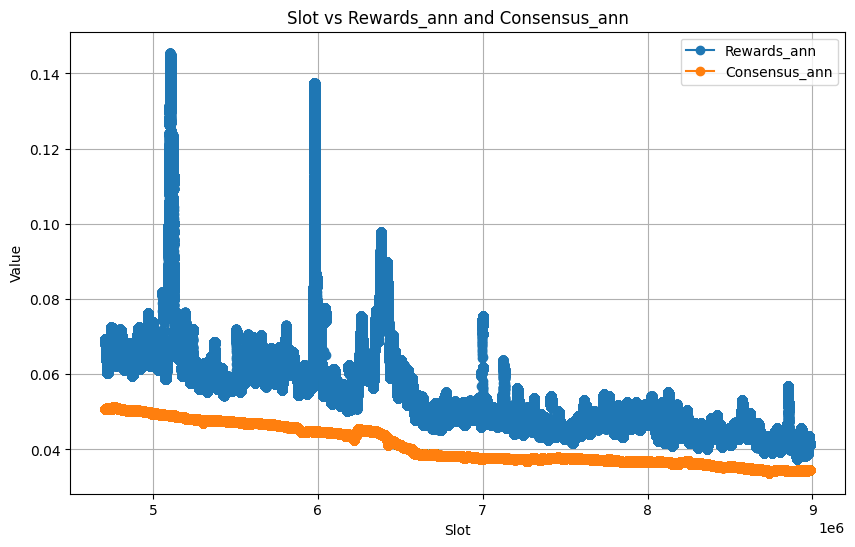

In [11]:
import matplotlib.pyplot as plt

window = 10000
df_ma = staked.rolling(window=window).mean()

plt.figure(figsize=(10, 6))
plt.plot(staked['slot'], df_ma['rewards_ann'], marker='o', label='Rewards_ann')
plt.plot(staked['slot'], df_ma['consensus_ann'], marker='o', label='Consensus_ann')
plt.xlabel('Slot')
plt.ylabel('Value')
plt.title('Slot vs Rewards_ann and Consensus_ann')
plt.legend()
plt.grid(True)
plt.show()

In [12]:
import matplotlib.pyplot as plt
import pandas as pd


# Calculate the frequency of each unique value in the 'withdrawal_address' column
metadata_no_duplicates = metadata.drop_duplicates(subset=['withdrawal_address'])

value_counts = metadata_no_duplicates['pool_size'].value_counts().sort_index()

print(value_counts)

1.0         13351
2.0          2012
3.0          1201
4.0           681
5.0           494
            ...  
37587.0     23065
59276.0         3
63125.0         2
209334.0     2406
339448.0        1
Name: pool_size, Length: 439, dtype: int64


In [14]:
staked_last_1m = staked.iloc[-1000000:]
staked_last_1m

,slot,consensus_cum,consensus+execution_cum,pool_consensus_cum,pool_rewards_cum,category_consensus_cum,category_rewards_cum,size_consensus_cum,size_rewards_cum,consensus_rewards,...,pool_rewards,category_rewards,pool_size_label_rewards,deposits,withdrawals,staked eth,execution,rewards_ann,consensus_ann,execution_ann
3284300,7984513,1.680134e+06,2.054947e+06,261031.938937,7.384227e+11,597215.383245,1.611149e+12,1.508393e+06,4.376101e+12,0.417534,...,Coinbase,CEX,100+,34577253.0,7.348937e+06,2.890845e+07,0.026811,0.040394,0.037957,0.002437
3284301,7984514,1.680134e+06,2.054948e+06,494615.095453,1.504235e+12,557100.088208,1.710196e+12,1.508393e+06,4.376103e+12,0.419482,...,Lido,Liquid Staking,100+,34577253.0,7.348937e+06,2.890845e+07,0.019115,0.039872,0.038134,0.001738
3284302,7984515,1.680134e+06,2.054948e+06,101.824904,5.118217e+08,74490.037183,2.074364e+11,1.508393e+06,4.376105e+12,0.420353,...,Mantle,Staking Pools,100+,34577253.0,7.348937e+06,2.890845e+07,0.041833,0.042016,0.038213,0.003803
3284303,7984516,1.680135e+06,2.054949e+06,6355.186369,2.648862e+10,557100.508581,1.710198e+12,1.508394e+06,4.376107e+12,0.420373,...,Frax,Liquid Staking,100+,34577253.0,7.348937e+06,2.890845e+07,0.140473,0.050985,0.038215,0.012770
3284304,7984517,1.680135e+06,2.054949e+06,261032.359169,7.384247e+11,597215.803478,1.611151e+12,1.508394e+06,4.376109e+12,0.420233,...,Coinbase,CEX,100+,34577253.0,7.348937e+06,2.890845e+07,0.046460,0.042426,0.038202,0.004224
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4284295,8984508,2.095525e+06,2.571802e+06,130350.095305,3.819650e+11,710898.067201,2.242234e+12,1.888827e+06,6.490000e+12,0.447497,...,Binance,CEX,100+,44260798.0,1.368459e+07,3.267174e+07,0.023700,0.037901,0.035995,0.001906
4284296,8984509,2.095525e+06,2.571802e+06,130350.540960,3.819676e+11,710898.512856,2.242237e+12,1.888827e+06,6.490002e+12,0.445655,...,Binance,CEX,100+,44260798.0,1.368459e+07,3.267174e+07,0.018735,0.037354,0.035847,0.001507
4284297,8984510,2.095526e+06,2.571803e+06,321958.865814,1.078435e+12,710898.959414,2.242240e+12,1.888828e+06,6.490005e+12,0.446558,...,Coinbase,CEX,100+,44260798.0,1.368459e+07,3.267174e+07,0.020702,0.037585,0.035920,0.001665
4284298,8984511,2.095526e+06,2.571803e+06,508973.173144,1.811776e+12,508973.173144,1.811776e+12,1.888828e+06,6.490007e+12,0.445900,...,Unidentified,Unidentified,100+,44260798.0,1.368459e+07,3.267174e+07,0.024221,0.037815,0.035867,0.001948


In [15]:
rewards_category = staked_last_1m.groupby('category_rewards')['rewards_ann'].mean()
rewards_pool = staked_last_1m.groupby('pool_rewards')['rewards_ann'].mean()
rewards_size = staked_last_1m.groupby('pool_size_label_rewards')['rewards_ann'].mean()

consensus_category = staked_last_1m.groupby('category_rewards')['consensus_ann'].mean()
consensus_pool = staked_last_1m.groupby('pool_rewards')['consensus_ann'].mean()
consensus_size = staked_last_1m.groupby('pool_size_label_rewards')['consensus_ann'].mean()

execution_category = staked_last_1m.groupby('category_rewards')['execution_ann'].mean()
execution_pool = staked_last_1m.groupby('pool_rewards')['execution_ann'].mean()
execution_size = staked_last_1m.groupby('pool_size_label_rewards')['execution_ann'].mean()

mean_rewards_ann = staked_last_1m['rewards_ann'].mean()
mean_consensus_ann = staked_last_1m['consensus_ann'].mean()
mean_execution_ann = staked_last_1m['execution_ann'].mean()

median_rewards_ann = staked_last_1m['rewards_ann'].median()
median_consensus_ann = staked_last_1m['consensus_ann'].median()
median_execution_ann = staked_last_1m['execution_ann'].median()


median_rewards_size = staked_last_1m.groupby('pool_size_label_rewards')['rewards_ann'].median()
median_consensus_size = staked_last_1m.groupby('pool_size_label_rewards')['consensus_ann'].median()
median_execution_size = staked_last_1m.groupby('pool_size_label_rewards')['execution_ann'].median()

median_rewards_pool = staked_last_1m.groupby('pool_rewards')['rewards_ann'].median()
median_consensus_pool = staked_last_1m.groupby('pool_rewards')['consensus_ann'].median()
median_execution_pool = staked_last_1m.groupby('pool_rewards')['execution_ann'].median()

median_rewards_category = staked_last_1m.groupby('category_rewards')['rewards_ann'].median()
median_consensus_category = staked_last_1m.groupby('category_rewards')['consensus_ann'].median()
median_execution_category = staked_last_1m.groupby('category_rewards')['execution_ann'].median()


print("Median Rewards:")
print(median_rewards_ann)

print("\nMedian Rewards ssize:")
print(median_rewards_size)

print("\nAverage Rewards:")
print(mean_rewards_ann)

print("\nAverage Rewards by Category:")
print(rewards_category)

print("\nAverage Rewards by Pool:")
print(rewards_pool)

print("\nAverage Rewards by Pool Size Label:")
print(rewards_size)

print("\nMedian Consensus:")
print(median_consensus_ann)

print("\nMedian Consensus ssize:")
print(median_consensus_size)

print("\nAvergae Consensus:")
print(mean_consensus_ann)

print("\nAverage Consensus by Category:")
print(consensus_category)

print("\nAverage Consensus by Pool:")
print(consensus_pool)

print("\nAverage Consensus by Pool Size Label:")
print(consensus_size)



print("\nMedian Execution:")
print(median_execution_ann)

print("\nMedian Execution ssize:")
print(median_execution_size)

print("\nAvergae Execution:")
print(mean_execution_ann)

print("\nAverage Execution by Category:")
print(execution_category)

print("\nAverage Execution by Pool:")
print(execution_pool)

print("\nAverage Execution by Pool Size Label:")
print(execution_size)

print("\nMedian rewards by Pool:")
print(median_rewards_pool)

print("\nMedian Consensus by Pool:")
print(median_consensus_pool)

print("\nMedian execution by Pool:")
print(median_execution_pool)

print("\nMedian rewards by category:")
print(median_rewards_category)

print("\nMedian Consensus by category:")
print(median_consensus_category)

print("\nMedian execution by category:")
print(median_execution_category)

Median Rewards:
0.04067932919543753

Median Rewards ssize:
pool_size_label_rewards
1        0.039511
2-5      0.039666
6-19     0.039995
20-99    0.039969
100+     0.040751
Name: rewards_ann, dtype: float64

Average Rewards:
0.04411566222737022

Average Rewards by Category:
category_rewards
CEX                 0.044232
Liquid Restaking    0.043970
Liquid Staking      0.044322
Solo Stakers        0.043065
Staking Pools       0.044623
Unidentified        0.043725
Name: rewards_ann, dtype: float64

Average Rewards by Pool:
pool_rewards
04221.eth         0.035630
0age.eth          0.043449
0dot1.eth         0.042379
0x201c.eth        0.000000
0x41414141.eth    0.050079
                    ...   
zuzaluan1.eth     0.000000
zyrb.eth          0.043020
꧰꧰꧰.eth           0.038997
🌱stake.eth        0.047006
👻👻👻👻👻👻.eth        0.019907
Name: rewards_ann, Length: 927, dtype: float64

Average Rewards by Pool Size Label:
pool_size_label_rewards
1        0.039470
2-5      0.043915
6-19     0.042380
20

In [ ]:
from scipy.stats import ttest_ind

pd.set_option('display.max_rows', None)


results = {}

for category, group in staked_last_1m.groupby('category_rewards'):
    t_stat, p_value = ttest_ind(group['rewards_ann'], staked_last_1m['rewards_ann'])
    results[category] = {'t_stat': t_stat, 'p_value': p_value, 'mean_diff': group['rewards_ann'].mean() - mean_rewards_ann}

for category, group in staked_last_1m.groupby('pool_rewards'):
    t_stat, p_value = ttest_ind(group['rewards_ann'], staked_last_1m['rewards_ann'])
    results[category] = {'t_stat': t_stat, 'p_value': p_value, 'mean_diff': group['rewards_ann'].mean() - mean_rewards_ann}

for category, group in staked_last_1m.groupby('pool_size_label_rewards'):
    t_stat, p_value = ttest_ind(group['rewards_ann'], staked_last_1m['rewards_ann'])
    results[category] = {'t_stat': t_stat, 'p_value': p_value, 'mean_diff': group['rewards_ann'].mean() - mean_rewards_ann}

    
# Display the results
results_df = pd.DataFrame(results).T
print(results_df)


results = {}

for category, group in staked_last_1m.groupby('category_rewards'):
    t_stat, p_value = ttest_ind(group['consensus_ann'], staked_last_1m['consensus_ann'])
    results[category] = {'t_stat': t_stat, 'p_value': p_value, 'mean_diff': group['consensus_ann'].mean() - mean_consensus_ann}

for category, group in staked_last_1m.groupby('pool_rewards'):
    t_stat, p_value = ttest_ind(group['consensus_ann'], staked_last_1m['consensus_ann'])
    results[category] = {'t_stat': t_stat, 'p_value': p_value, 'mean_diff': group['consensus_ann'].mean() - mean_consensus_ann}

for category, group in staked_last_1m.groupby('pool_size_label_rewards'):
    t_stat, p_value = ttest_ind(group['consensus_ann'], staked_last_1m['consensus_ann'])
    results[category] = {'t_stat': t_stat, 'p_value': p_value, 'mean_diff': group['consensus_ann'].mean() - mean_consensus_ann}

    
results_df = pd.DataFrame(results).T
print(results_df)



results = {}

for category, group in staked_last_1m.groupby('category_rewards'):
    t_stat, p_value = ttest_ind(group['execution_ann'], staked_last_1m['execution_ann'])
    results[category] = {'t_stat': t_stat, 'p_value': p_value, 'mean_diff': group['execution_ann'].mean() - mean_execution_ann}

for category, group in staked_last_1m.groupby('pool_rewards'):
    t_stat, p_value = ttest_ind(group['execution_ann'], staked_last_1m['execution_ann'])
    results[category] = {'t_stat': t_stat, 'p_value': p_value, 'mean_diff': group['execution_ann'].mean() - mean_execution_ann}

for category, group in staked_last_1m.groupby('pool_size_label_rewards'):
    t_stat, p_value = ttest_ind(group['execution_ann'], staked_last_1m['execution_ann'])
    results[category] = {'t_stat': t_stat, 'p_value': p_value, 'mean_diff': group['execution_ann'].mean() - mean_execution_ann}

    
results_df = pd.DataFrame(results).T
print(results_df)

In [17]:
value_counts_category_rewards = staked_last_1m['category_rewards'].value_counts()
value_counts_pool_rewards = staked_last_1m['pool_rewards'].value_counts()
value_counts_pool_size_label_rewards = staked_last_1m['pool_size_label_rewards'].value_counts()

print("Value counts for 'category_rewards':")
print(value_counts_category_rewards)

print("\nValue counts for 'pool_rewards':")
print(value_counts_pool_rewards)

print("\nValue counts for 'pool_size_label_rewards':")
print(value_counts_pool_size_label_rewards)


Value counts for 'category_rewards':
Liquid Staking      357121
Unidentified        277188
CEX                 273776
Staking Pools        46703
Liquid Restaking     29205
Solo Stakers         16007
Name: category_rewards, dtype: int64

Value counts for 'pool_rewards':
Lido                                       312012
Unidentified                               277188
Coinbase                                   147345
Binance                                     39461
Rocketpool                                  27308
Kraken                                      25731
OKX                                         15914
Bitcoin Suisse                              15462
Ledger Live                                 14977
Ether.Fi                                    14258
Mantle                                      12962
Upbit                                       12195
DARMA Capital                               10949
Renzo                                        8183
Frax                          

In [19]:
#staked.to_csv('staked_processed.csv', index=False)

In [ ]:
import numpy as np

# Generate D values
D_values = np.arange(20_000_000, 120_000_001, 1_000)

mean_execution = 191178.27657596106
median_execution = 82587.80682206163

# Calculate Current Curve values
current_curve_values = (2.6 * 64) / np.sqrt(D_values) + mean_execution / D_values
anders_curve_values = (2.6 * 64) / (np.sqrt(D_values) * (1 + D_values * 2**(-25))) + mean_execution / D_values
anders_graduated_curve_values = (2.6 * 64) / (np.sqrt(D_values) * (1 + D_values * 2**(-26))) + mean_execution / D_values

buterin_cap_curve_values = (2.6 * 64) * (1 / np.sqrt(D_values) - 0.5 / (np.sqrt(2**25 - D_values))) + mean_execution / D_values
anders_dark_green = (2.6 * 32) / np.sqrt(D_values)
anders_orange = (2.6 * 64) / (np.sqrt(D_values) + D_values * 0.00015)
anders_pink = (2.6 * 48) / (np.sqrt(D_values) + (D_values * 2**(-19))**2)
anders_dark_purple = (2.6 * 64) / (np.sqrt(D_values) + D_values * 2**(-14) + (D_values * 2**(-19))**2)
anders_dark_purple_dash = (2.6 * 64) / (np.sqrt(D_values) + D_values * 2**(-13) + (D_values * 2**(-20))**2)


# Create DataFrame
curves = pd.DataFrame({
    'D': D_values,
    'Current Curve': current_curve_values,
    'Anders Curve': anders_curve_values,
    'Anders Graduated Curve': anders_graduated_curve_values,
    #'Buterin Cap Curve': buterin_cap_curve_values,
    #'Anders Dark Green': anders_dark_green,
    #'Anders Orange': anders_orange,
    #'Anders Pink': anders_pink,
    #'Anders Dark Purple': anders_dark_purple,
    #'Anders Dark Purple Dash': anders_dark_purple_dash
})

curves


In [21]:
min_consensus = .0332 / .0354
max_consensus = .0355 / .0354
min_execution = .0027 * 22040000
max_execution = .0087 * 22040000

supply_point = 32000000
#curves = curves.drop(columns=['Buterin Cap Curve'])

for col in curves.columns:
    #curves[f'min {col}'] = curves[col] * min_consensus
    #curves[f'max {col}'] = curves[col] * max_consensus
    
    #curves[f'min mev {col}'] = curves[col] * min_consensus + min_execution / curves['D']
    #curves[f'max mev {col}'] = curves[col] * max_consensus + max_execution / curves['D']
    print(col)
    print((curves.iloc[2000][col] * max_consensus + max_execution / supply_point) / (curves.iloc[2000][col] * min_consensus + min_execution / supply_point))

#curves = curves.drop(columns=['min mev D', 'max mev D'])
#curves = curves.drop(columns=['min D', 'max D', 'min mev D', 'max mev D'])

print(curves[curves['D'] == supply_point])
#curves

D
1.0692771086277792
Current Curve
1.1617805089221693
Anders Curve
1.2022654761022682
Anders Graduated Curve
1.1834495214423264
              D  Current Curve  Anders Curve  Anders Graduated Curve
12000  32000000        0.03539      0.021031                0.025892


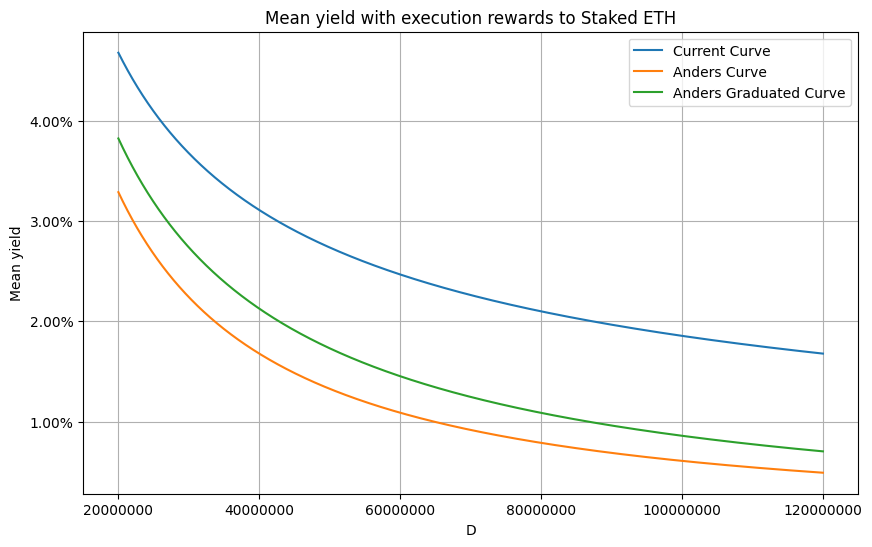

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
from matplotlib.ticker import FuncFormatter


plt.figure(figsize=(10, 6))

# Loop through each column (except 'D') and plot against 'D'
for column in curves.columns:
    if column != 'D':
        plt.plot(curves['D'], curves[column], label=column)

plt.title('Mean yield with execution rewards to Staked ETH')
plt.xlabel('D')
plt.ylabel('Mean yield')

plt.legend()

plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x)}'))
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y*100:.2f}%'))

plt.grid(True)
plt.show()


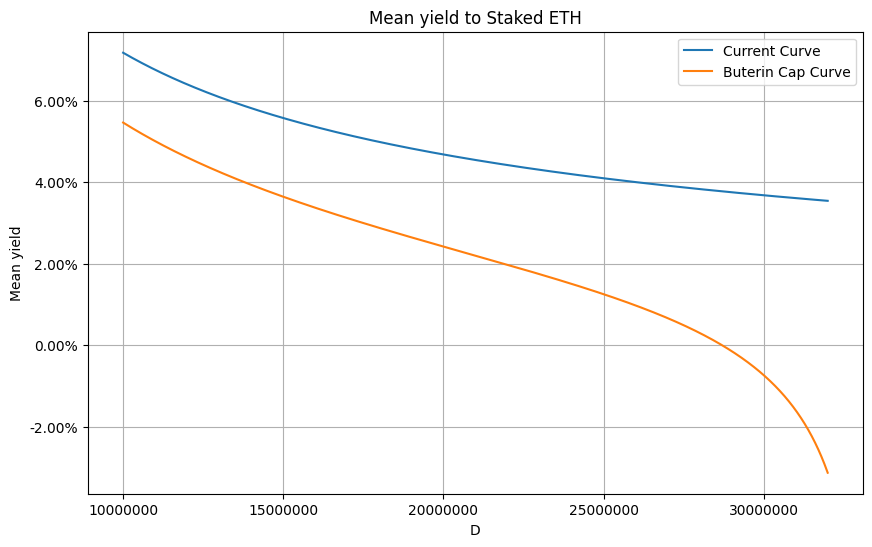

In [23]:
import numpy as np

# Generate D values
D_values = np.arange(10_000_000, 32_000_001, 1_000)

mean_execution = 191178.27657596106
median_execution = 82587.80682206163

# Calculate Current Curve values
current_curve_values = (2.6 * 64) / np.sqrt(D_values) + mean_execution / D_values
anders_curve_values = (2.6 * 64) / (np.sqrt(D_values) * (1 + D_values * 2**(-25))) + mean_execution / D_values
anders_graduated_curve_values = (2.6 * 64) / (np.sqrt(D_values) * (1 + D_values * 2**(-26))) + mean_execution / D_values

buterin_cap_curve_values = (2.6 * 64) * (1 / np.sqrt(D_values) - 0.5 / (np.sqrt(2**25 - D_values))) + mean_execution / D_values
anders_dark_green = (2.6 * 32) / np.sqrt(D_values)
anders_orange = (2.6 * 64) / (np.sqrt(D_values) + D_values * 0.00015)
anders_pink = (2.6 * 48) / (np.sqrt(D_values) + (D_values * 2**(-19))**2)
anders_dark_purple = (2.6 * 64) / (np.sqrt(D_values) + D_values * 2**(-14) + (D_values * 2**(-19))**2)
anders_dark_purple_dash = (2.6 * 64) / (np.sqrt(D_values) + D_values * 2**(-13) + (D_values * 2**(-20))**2)


# Create DataFrame
curves = pd.DataFrame({
    'D': D_values,
    'Current Curve': current_curve_values,
    #'Anders Curve': anders_curve_values,
    #'Anders Graduated Curve': anders_graduated_curve_values,
    'Buterin Cap Curve': buterin_cap_curve_values,
    #'Anders Dark Green': anders_dark_green,
    #'Anders Orange': anders_orange,
    #'Anders Pink': anders_pink,
    #'Anders Dark Purple': anders_dark_purple,
    #'Anders Dark Purple Dash': anders_dark_purple_dash
})

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
from matplotlib.ticker import FuncFormatter


plt.figure(figsize=(10, 6))

# Loop through each column (except 'D') and plot against 'D'
for column in curves.columns:
    if column != 'D':
        plt.plot(curves['D'], curves[column], label=column)

plt.title('Mean yield to Staked ETH')
plt.xlabel('D')
plt.ylabel('Mean yield')

plt.legend()

plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x)}'))
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y*100:.2f}%'))

plt.grid(True)
plt.show()


/var/folders/rk/6s502r195ws9c0w51r69l8s80000gn/T/ipykernel_24093/3432581660.py:14: RuntimeWarning: invalid value encountered in sqrt
  buterin_cap_curve_values = (2.6 * 64) * (1 / np.sqrt(D_values) - 0.5 / (np.sqrt(2**25 - D_values))) + mean_execution / D_values


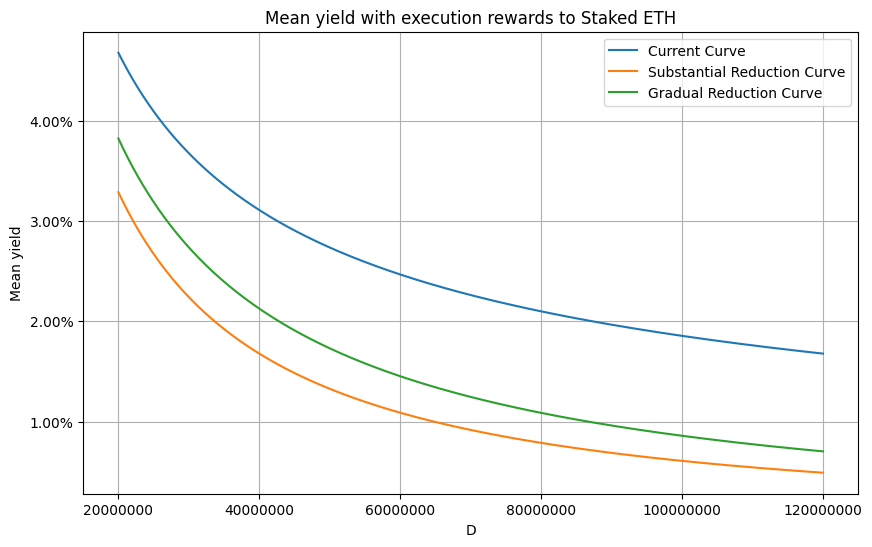

In [24]:
import numpy as np

# Generate D values
D_values = np.arange(20_000_000, 120_000_001, 1_000)

mean_execution = 191178.27657596106
median_execution = 82587.80682206163

# Calculate Current Curve values
current_curve_values = (2.6 * 64) / np.sqrt(D_values) + mean_execution / D_values
anders_curve_values = (2.6 * 64) / (np.sqrt(D_values) * (1 + D_values * 2**(-25))) + mean_execution / D_values
anders_graduated_curve_values = (2.6 * 64) / (np.sqrt(D_values) * (1 + D_values * 2**(-26))) + mean_execution / D_values

buterin_cap_curve_values = (2.6 * 64) * (1 / np.sqrt(D_values) - 0.5 / (np.sqrt(2**25 - D_values))) + mean_execution / D_values
anders_dark_green = (2.6 * 32) / np.sqrt(D_values)
anders_orange = (2.6 * 64) / (np.sqrt(D_values) + D_values * 0.00015)
anders_pink = (2.6 * 48) / (np.sqrt(D_values) + (D_values * 2**(-19))**2)
anders_dark_purple = (2.6 * 64) / (np.sqrt(D_values) + D_values * 2**(-14) + (D_values * 2**(-19))**2)
anders_dark_purple_dash = (2.6 * 64) / (np.sqrt(D_values) + D_values * 2**(-13) + (D_values * 2**(-20))**2)


# Create DataFrame
curves = pd.DataFrame({
    'D': D_values,
    'Current Curve': current_curve_values,
    'Substantial Reduction Curve': anders_curve_values,
    'Gradual Reduction Curve': anders_graduated_curve_values,
    #'Economically Capped Curve': buterin_cap_curve_values,
    #'Anders Dark Green': anders_dark_green,
    #'Anders Orange': anders_orange,
    #'Anders Pink': anders_pink,
    #'Anders Dark Purple': anders_dark_purple,
    #'Anders Dark Purple Dash': anders_dark_purple_dash
})

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
from matplotlib.ticker import FuncFormatter


plt.figure(figsize=(10, 6))

# Loop through each column (except 'D') and plot against 'D'
for column in curves.columns:
    if column != 'D':
        plt.plot(curves['D'], curves[column], label=column)

plt.title('Mean yield with execution rewards to Staked ETH')
plt.xlabel('D')
plt.ylabel('Mean yield')

plt.legend()

plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x)}'))
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y*100:.2f}%'))

plt.grid(True)
plt.show()


/var/folders/rk/6s502r195ws9c0w51r69l8s80000gn/T/ipykernel_24093/680973876.py:14: RuntimeWarning: invalid value encountered in sqrt
  buterin_cap_curve_values = (2.6 * 64) * (1 / np.sqrt(D_values) - 0.5 / (np.sqrt(2**25 - D_values))) #+ mean_execution / D_values


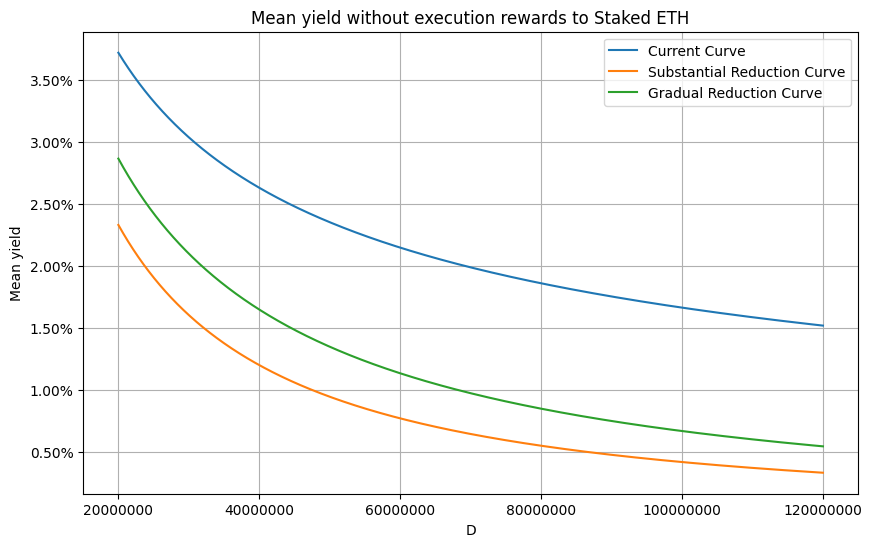

In [25]:
import numpy as np

# Generate D values
D_values = np.arange(20_000_000, 120_000_001, 1_000)

mean_execution = 191178.27657596106
median_execution = 82587.80682206163

# Calculate Current Curve values
current_curve_values = (2.6 * 64) / np.sqrt(D_values) #+ mean_execution / D_values
anders_curve_values = (2.6 * 64) / (np.sqrt(D_values) * (1 + D_values * 2**(-25))) #+ mean_execution / D_values
anders_graduated_curve_values = (2.6 * 64) / (np.sqrt(D_values) * (1 + D_values * 2**(-26))) #+ mean_execution / D_values

buterin_cap_curve_values = (2.6 * 64) * (1 / np.sqrt(D_values) - 0.5 / (np.sqrt(2**25 - D_values))) #+ mean_execution / D_values
anders_dark_green = (2.6 * 32) / np.sqrt(D_values)
anders_orange = (2.6 * 64) / (np.sqrt(D_values) + D_values * 0.00015)
anders_pink = (2.6 * 48) / (np.sqrt(D_values) + (D_values * 2**(-19))**2)
anders_dark_purple = (2.6 * 64) / (np.sqrt(D_values) + D_values * 2**(-14) + (D_values * 2**(-19))**2)
anders_dark_purple_dash = (2.6 * 64) / (np.sqrt(D_values) + D_values * 2**(-13) + (D_values * 2**(-20))**2)


# Create DataFrame
curves = pd.DataFrame({
    'D': D_values,
    'Current Curve': current_curve_values,
    'Substantial Reduction Curve': anders_curve_values,
    'Gradual Reduction Curve': anders_graduated_curve_values,
    #'Economically Capped Curve': buterin_cap_curve_values,
    #'Anders Dark Green': anders_dark_green,
    #'Anders Orange': anders_orange,
    #'Anders Pink': anders_pink,
    #'Anders Dark Purple': anders_dark_purple,
    #'Anders Dark Purple Dash': anders_dark_purple_dash
})

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
from matplotlib.ticker import FuncFormatter


plt.figure(figsize=(10, 6))

# Loop through each column (except 'D') and plot against 'D'
for column in curves.columns:
    if column != 'D':
        plt.plot(curves['D'], curves[column], label=column)

plt.title('Mean yield without execution rewards to Staked ETH')
plt.xlabel('D')
plt.ylabel('Mean yield')

plt.legend()

plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x)}'))
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y*100:.2f}%'))

plt.grid(True)
plt.show()


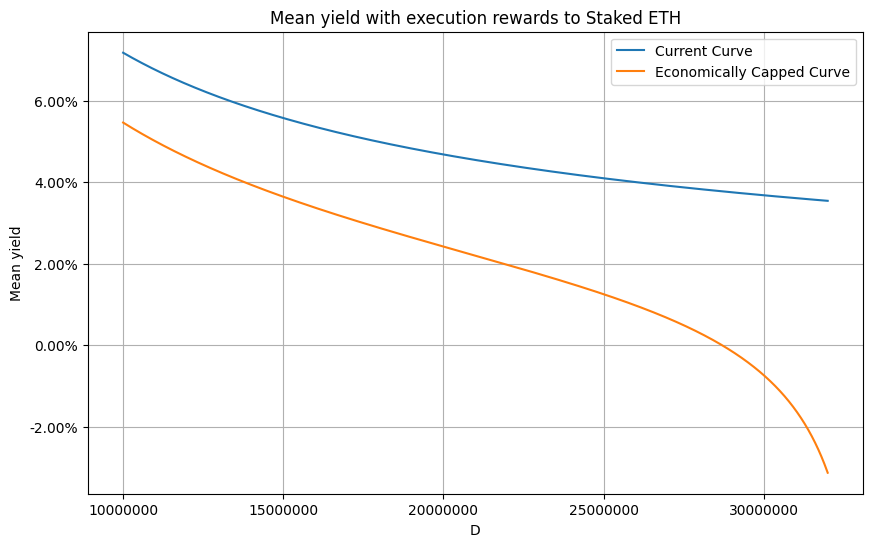

In [26]:
import numpy as np

# Generate D values
D_values = np.arange(10_000_000, 32_000_001, 1_000)

mean_execution = 191178.27657596106
median_execution = 82587.80682206163

# Calculate Current Curve values
current_curve_values = (2.6 * 64) / np.sqrt(D_values) + mean_execution / D_values
anders_curve_values = (2.6 * 64) / (np.sqrt(D_values) * (1 + D_values * 2**(-25))) + mean_execution / D_values
anders_graduated_curve_values = (2.6 * 64) / (np.sqrt(D_values) * (1 + D_values * 2**(-26))) + mean_execution / D_values

buterin_cap_curve_values = (2.6 * 64) * (1 / np.sqrt(D_values) - 0.5 / (np.sqrt(2**25 - D_values))) + mean_execution / D_values
anders_dark_green = (2.6 * 32) / np.sqrt(D_values)
anders_orange = (2.6 * 64) / (np.sqrt(D_values) + D_values * 0.00015)
anders_pink = (2.6 * 48) / (np.sqrt(D_values) + (D_values * 2**(-19))**2)
anders_dark_purple = (2.6 * 64) / (np.sqrt(D_values) + D_values * 2**(-14) + (D_values * 2**(-19))**2)
anders_dark_purple_dash = (2.6 * 64) / (np.sqrt(D_values) + D_values * 2**(-13) + (D_values * 2**(-20))**2)


# Create DataFrame
curves = pd.DataFrame({
    'D': D_values,
    'Current Curve': current_curve_values,
    #'Substancial Reduction Curve': anders_curve_values,
    #'Graduated Reduction Curve': anders_graduated_curve_values,
    'Economically Capped Curve': buterin_cap_curve_values,
    #'Anders Dark Green': anders_dark_green,
    #'Anders Orange': anders_orange,
    #'Anders Pink': anders_pink,
    #'Anders Dark Purple': anders_dark_purple,
    #'Anders Dark Purple Dash': anders_dark_purple_dash
})

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
from matplotlib.ticker import FuncFormatter


plt.figure(figsize=(10, 6))

# Loop through each column (except 'D') and plot against 'D'
for column in curves.columns:
    if column != 'D':
        plt.plot(curves['D'], curves[column], label=column)

plt.title('Mean yield with execution rewards to Staked ETH')
plt.xlabel('D')
plt.ylabel('Mean yield')

plt.legend()

plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x)}'))
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y*100:.2f}%'))

plt.grid(True)
plt.show()


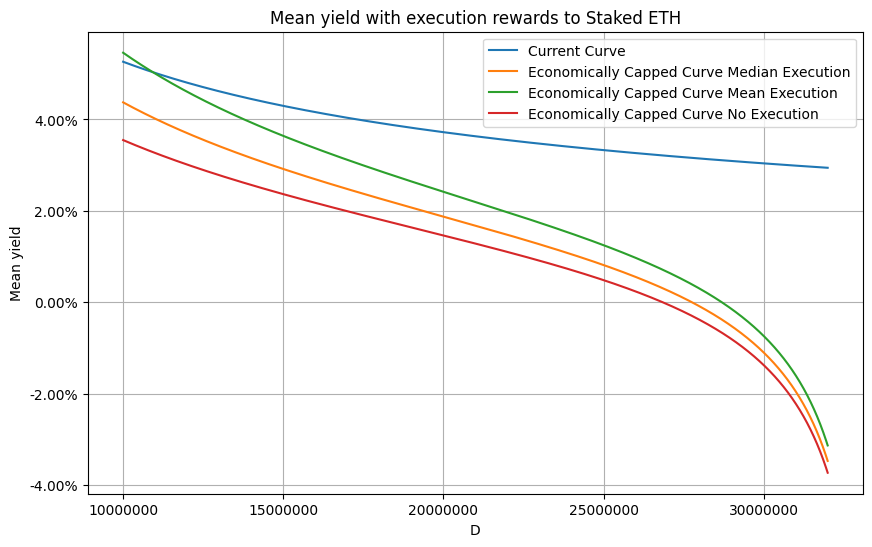

In [27]:
import numpy as np

# Generate D values
D_values = np.arange(10_000_000, 32_000_001, 1_000)

mean_execution = 191178.27657596106
median_execution = 82587.80682206163

# Calculate Current Curve values
current_curve_values = (2.6 * 64) / np.sqrt(D_values) #+ mean_execution / D_values
anders_curve_values = (2.6 * 64) / (np.sqrt(D_values) * (1 + D_values * 2**(-25)))# + mean_execution / D_values
anders_graduated_curve_values = (2.6 * 64) / (np.sqrt(D_values) * (1 + D_values * 2**(-26)))# + mean_execution / D_values

buterin_cap_curve_values_mean = (2.6 * 64) * (1 / np.sqrt(D_values) - 0.5 / (np.sqrt(2**25 - D_values))) + mean_execution / D_values
buterin_cap_curve_values_median = (2.6 * 64) * (1 / np.sqrt(D_values) - 0.5 / (np.sqrt(2**25 - D_values))) + median_execution / D_values
buterin_cap_curve_values = (2.6 * 64) * (1 / np.sqrt(D_values) - 0.5 / (np.sqrt(2**25 - D_values))) #+ mean_execution / D_values


anders_dark_green = (2.6 * 32) / np.sqrt(D_values)
anders_orange = (2.6 * 64) / (np.sqrt(D_values) + D_values * 0.00015)
anders_pink = (2.6 * 48) / (np.sqrt(D_values) + (D_values * 2**(-19))**2)
anders_dark_purple = (2.6 * 64) / (np.sqrt(D_values) + D_values * 2**(-14) + (D_values * 2**(-19))**2)
anders_dark_purple_dash = (2.6 * 64) / (np.sqrt(D_values) + D_values * 2**(-13) + (D_values * 2**(-20))**2)


# Create DataFrame
curves = pd.DataFrame({
    'D': D_values,
    'Current Curve': current_curve_values,
    #'Substancial Reduction Curve': anders_curve_values,
    #'Graduated Reduction Curve': anders_graduated_curve_values,
    'Economically Capped Curve Median Execution': buterin_cap_curve_values_median,
    'Economically Capped Curve Mean Execution': buterin_cap_curve_values_mean,
    'Economically Capped Curve No Execution': buterin_cap_curve_values,
    #'Anders Dark Green': anders_dark_green,
    #'Anders Orange': anders_orange,
    #'Anders Pink': anders_pink,
    #'Anders Dark Purple': anders_dark_purple,
    #'Anders Dark Purple Dash': anders_dark_purple_dash
})

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
from matplotlib.ticker import FuncFormatter


plt.figure(figsize=(10, 6))

# Loop through each column (except 'D') and plot against 'D'
for column in curves.columns:
    if column != 'D':
        plt.plot(curves['D'], curves[column], label=column)

plt.title('Mean yield with execution rewards to Staked ETH')
plt.xlabel('D')
plt.ylabel('Mean yield')

plt.legend()

plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x)}'))
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y*100:.2f}%'))

plt.grid(True)
plt.show()


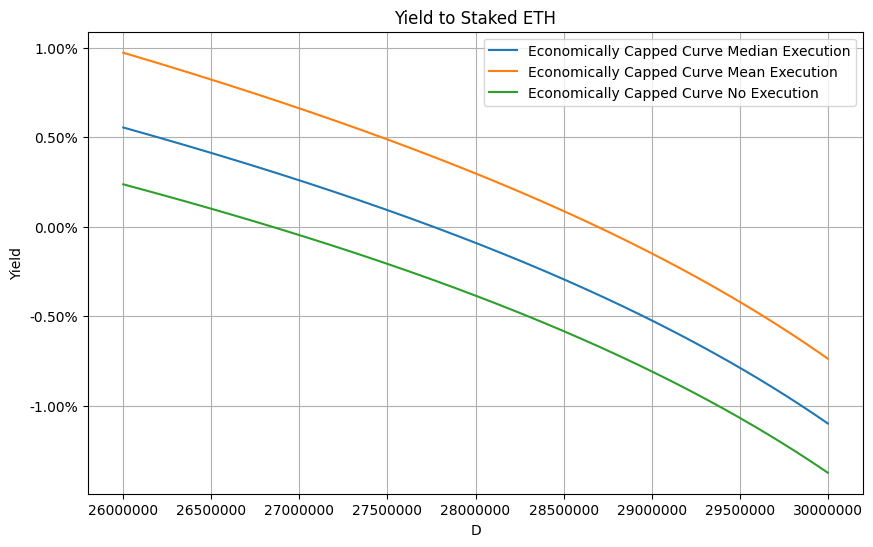

In [28]:
import numpy as np

# Generate D values
D_values = np.arange(26_000_000, 30_000_001, 1_000)

mean_execution = 191178.27657596106
median_execution = 82587.80682206163

# Calculate Current Curve values
current_curve_values = (2.6 * 64) / np.sqrt(D_values) #+ mean_execution / D_values
anders_curve_values = (2.6 * 64) / (np.sqrt(D_values) * (1 + D_values * 2**(-25)))# + mean_execution / D_values
anders_graduated_curve_values = (2.6 * 64) / (np.sqrt(D_values) * (1 + D_values * 2**(-26)))# + mean_execution / D_values

buterin_cap_curve_values_mean = (2.6 * 64) * (1 / np.sqrt(D_values) - 0.5 / (np.sqrt(2**25 - D_values))) + mean_execution / D_values
buterin_cap_curve_values_median = (2.6 * 64) * (1 / np.sqrt(D_values) - 0.5 / (np.sqrt(2**25 - D_values))) + median_execution / D_values
buterin_cap_curve_values = (2.6 * 64) * (1 / np.sqrt(D_values) - 0.5 / (np.sqrt(2**25 - D_values))) #+ mean_execution / D_values


anders_dark_green = (2.6 * 32) / np.sqrt(D_values)
anders_orange = (2.6 * 64) / (np.sqrt(D_values) + D_values * 0.00015)
anders_pink = (2.6 * 48) / (np.sqrt(D_values) + (D_values * 2**(-19))**2)
anders_dark_purple = (2.6 * 64) / (np.sqrt(D_values) + D_values * 2**(-14) + (D_values * 2**(-19))**2)
anders_dark_purple_dash = (2.6 * 64) / (np.sqrt(D_values) + D_values * 2**(-13) + (D_values * 2**(-20))**2)


# Create DataFrame
curves = pd.DataFrame({
    'D': D_values,
    #'Current Curve': current_curve_values,
    #'Substancial Reduction Curve': anders_curve_values,
    #'Graduated Reduction Curve': anders_graduated_curve_values,
    'Economically Capped Curve Median Execution': buterin_cap_curve_values_median,
    'Economically Capped Curve Mean Execution': buterin_cap_curve_values_mean,
    'Economically Capped Curve No Execution': buterin_cap_curve_values,
    #'Anders Dark Green': anders_dark_green,
    #'Anders Orange': anders_orange,
    #'Anders Pink': anders_pink,
    #'Anders Dark Purple': anders_dark_purple,
    #'Anders Dark Purple Dash': anders_dark_purple_dash
})

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
from matplotlib.ticker import FuncFormatter


plt.figure(figsize=(10, 6))

# Loop through each column (except 'D') and plot against 'D'
for column in curves.columns:
    if column != 'D':
        plt.plot(curves['D'], curves[column], label=column)

plt.title('Yield to Staked ETH')
plt.xlabel('D')
plt.ylabel('Yield')

plt.legend()

plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x)}'))
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y*100:.2f}%'))

plt.grid(True)
plt.show()


/var/folders/rk/6s502r195ws9c0w51r69l8s80000gn/T/ipykernel_24093/2698622045.py:14: RuntimeWarning: invalid value encountered in sqrt
  buterin_cap_curve_values = (2.6 * 64) * (1 / np.sqrt(D_values) - 0.5 / (np.sqrt(2**25 - D_values))) + median_execution / D_values


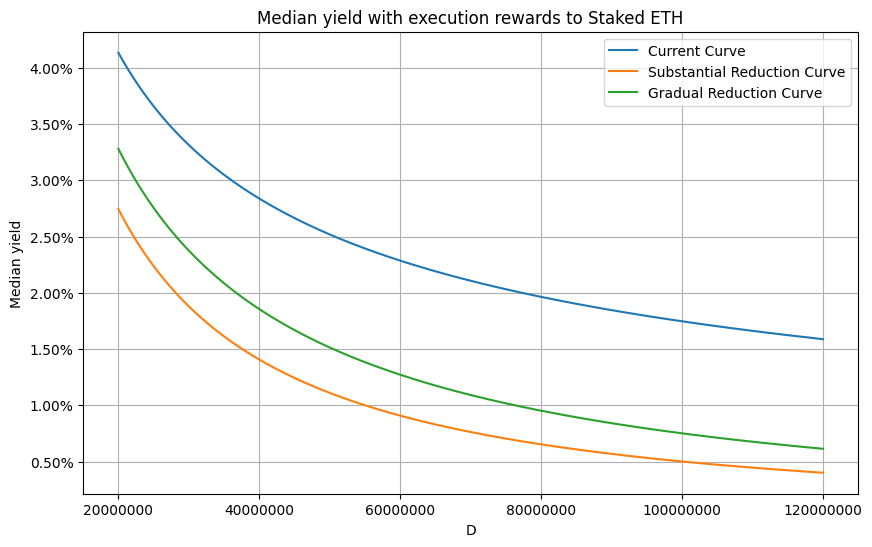

In [29]:
import numpy as np

# Generate D values
D_values = np.arange(20_000_000, 120_000_001, 1_000)

mean_execution = 191178.27657596106
median_execution = 82587.80682206163

# Calculate Current Curve values
current_curve_values = (2.6 * 64) / np.sqrt(D_values) + median_execution / D_values
anders_curve_values = (2.6 * 64) / (np.sqrt(D_values) * (1 + D_values * 2**(-25))) + median_execution / D_values
anders_graduated_curve_values = (2.6 * 64) / (np.sqrt(D_values) * (1 + D_values * 2**(-26))) + median_execution / D_values

buterin_cap_curve_values = (2.6 * 64) * (1 / np.sqrt(D_values) - 0.5 / (np.sqrt(2**25 - D_values))) + median_execution / D_values
anders_dark_green = (2.6 * 32) / np.sqrt(D_values)
anders_orange = (2.6 * 64) / (np.sqrt(D_values) + D_values * 0.00015)
anders_pink = (2.6 * 48) / (np.sqrt(D_values) + (D_values * 2**(-19))**2)
anders_dark_purple = (2.6 * 64) / (np.sqrt(D_values) + D_values * 2**(-14) + (D_values * 2**(-19))**2)
anders_dark_purple_dash = (2.6 * 64) / (np.sqrt(D_values) + D_values * 2**(-13) + (D_values * 2**(-20))**2)


# Create DataFrame
curves = pd.DataFrame({
    'D': D_values,
    'Current Curve': current_curve_values,
    'Substantial Reduction Curve': anders_curve_values,
    'Gradual Reduction Curve': anders_graduated_curve_values,
    #'Economically Capped Curve': buterin_cap_curve_values,
    #'Anders Dark Green': anders_dark_green,
    #'Anders Orange': anders_orange,
    #'Anders Pink': anders_pink,
    #'Anders Dark Purple': anders_dark_purple,
    #'Anders Dark Purple Dash': anders_dark_purple_dash
})

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
from matplotlib.ticker import FuncFormatter


plt.figure(figsize=(10, 6))

# Loop through each column (except 'D') and plot against 'D'
for column in curves.columns:
    if column != 'D':
        plt.plot(curves['D'], curves[column], label=column)

plt.title('Median yield with execution rewards to Staked ETH')
plt.xlabel('D')
plt.ylabel('Median yield')

plt.legend()

plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x)}'))
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y*100:.2f}%'))

plt.grid(True)
plt.show()


/var/folders/rk/6s502r195ws9c0w51r69l8s80000gn/T/ipykernel_24093/3307859121.py:26: RuntimeWarning: invalid value encountered in sqrt
  buterin_cap_curve_values = (2.6 * 64) * (1 / np.sqrt(D_values) - 0.5 / (np.sqrt(2**25 - D_values))) + mean_execution / D_values


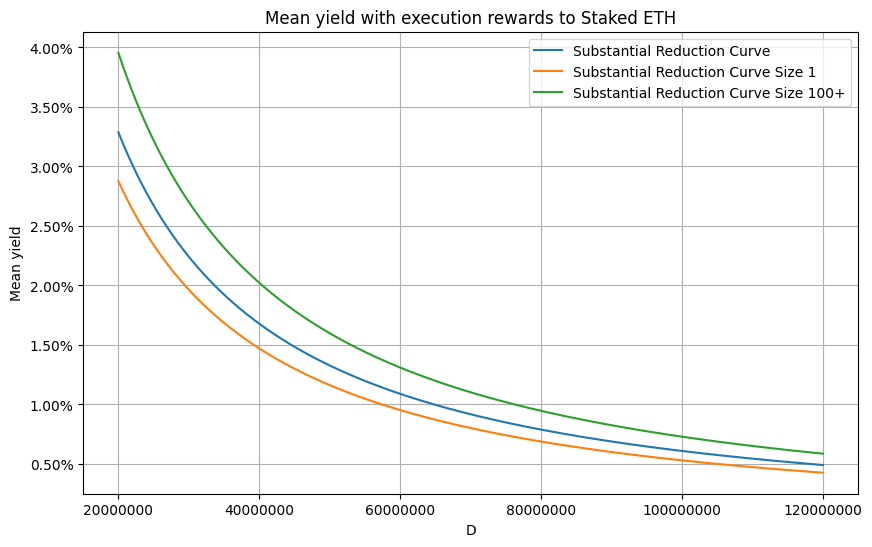

In [30]:
import numpy as np

# Generate D values
D_values = np.arange(20_000_000, 120_000_001, 1_000)

mean_execution = 191178.27657596106
mean_execution_1 = 191178.27657596106 * 0.6314 / 0.8674
mean_execution_5 = 191178.27657596106 * 0.8729 / 0.8674

mean_ret = 3.5442
multiplier_1 = 3.3156 / mean_ret
multiplier_5 = 4.5509 / mean_ret


median_execution = 82587.80682206163

# Calculate Current Curve values
current_curve_values = (2.6 * 64) / np.sqrt(D_values) + mean_execution / D_values
anders_curve_values_1 = (2.6 * 64) * multiplier_1 / (np.sqrt(D_values) * (1 + D_values * 2**(-25))) + mean_execution_1 / D_values
anders_curve_values_5 = (2.6 * 64) * multiplier_5 / (np.sqrt(D_values) * (1 + D_values * 2**(-25))) + mean_execution_5 / D_values
anders_curve_values = (2.6 * 64) / (np.sqrt(D_values) * (1 + D_values * 2**(-25))) + mean_execution / D_values


anders_graduated_curve_values = (2.6 * 64) / (np.sqrt(D_values) * (1 + D_values * 2**(-26))) + mean_execution / D_values

buterin_cap_curve_values = (2.6 * 64) * (1 / np.sqrt(D_values) - 0.5 / (np.sqrt(2**25 - D_values))) + mean_execution / D_values

comparion = ((2.6 * 64) * multiplier_5 / (np.sqrt(D_values) * (1 + D_values * 2**(-25))) + mean_execution_5 / D_values) / ((2.6 * 64) * multiplier_1 / (np.sqrt(D_values) * (1 + D_values * 2**(-25))) + mean_execution_1 / D_values)

# Create DataFrame
curves = pd.DataFrame({
    'D': D_values,
    #'Current Curve': current_curve_values,
    'Substantial Reduction Curve': anders_curve_values,
    'Substantial Reduction Curve Size 1': anders_curve_values_1,
    'Substantial Reduction Curve Size 100+': anders_curve_values_5,
    #'comparion': comparion,
    #'Graduated Reduction Curve': anders_graduated_curve_values,
    #'Economically Capped Curve': buterin_cap_curve_values,
    #'Anders Dark Green': anders_dark_green,
    #'Anders Orange': anders_orange,
    #'Anders Pink': anders_pink,
    #'Anders Dark Purple': anders_dark_purple,
    #'Anders Dark Purple Dash': anders_dark_purple_dash
})

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
from matplotlib.ticker import FuncFormatter


plt.figure(figsize=(10, 6))

# Loop through each column (except 'D') and plot against 'D'
for column in curves.columns:
    if column != 'D':
        plt.plot(curves['D'], curves[column], label=column)

plt.title('Mean yield with execution rewards to Staked ETH')
plt.xlabel('D')
plt.ylabel('Mean yield')

plt.legend()

plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x)}'))
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y*100:.2f}%'))

plt.grid(True)
plt.show()


/var/folders/rk/6s502r195ws9c0w51r69l8s80000gn/T/ipykernel_24093/713518447.py:28: RuntimeWarning: invalid value encountered in sqrt
  buterin_cap_curve_values = (2.6 * 64) * (1 / np.sqrt(D_values) - 0.5 / (np.sqrt(2**25 - D_values))) + mean_execution / D_values


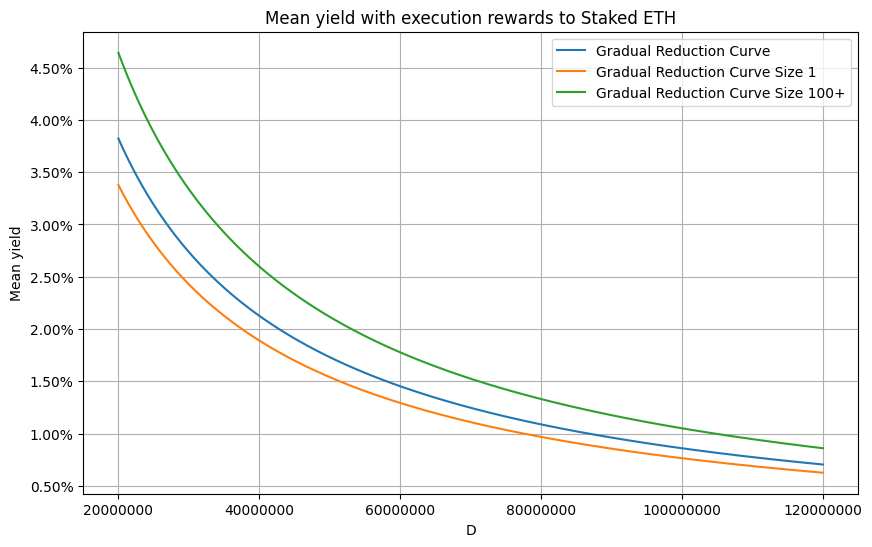

In [31]:
import numpy as np

# Generate D values
D_values = np.arange(20_000_000, 120_000_001, 1_000)

mean_execution = 191178.27657596106
mean_execution_1 = 191178.27657596106 * 0.6314 / 0.8674
mean_execution_5 = 191178.27657596106 * 0.8729 / 0.8674

mean_ret = 3.5442
multiplier_1 = 3.3156 / mean_ret
multiplier_5 = 4.5509 / mean_ret


median_execution = 82587.80682206163

# Calculate Current Curve values
current_curve_values = (2.6 * 64) / np.sqrt(D_values) + mean_execution / D_values
anders_curve_values_1 = (2.6 * 64) * multiplier_1 / (np.sqrt(D_values) * (1 + D_values * 2**(-25))) + mean_execution_1 / D_values
anders_curve_values_5 = (2.6 * 64) * multiplier_5 / (np.sqrt(D_values) * (1 + D_values * 2**(-25))) + mean_execution_5 / D_values
anders_curve_values = (2.6 * 64) / (np.sqrt(D_values) * (1 + D_values * 2**(-25))) + mean_execution / D_values


anders_graduated_curve_values = (2.6 * 64) / (np.sqrt(D_values) * (1 + D_values * 2**(-26))) + mean_execution / D_values
anders_curve_values_1 = (2.6 * 64) * multiplier_1 / (np.sqrt(D_values) * (1 + D_values * 2**(-26))) + mean_execution_1 / D_values
anders_curve_values_5 = (2.6 * 64) * multiplier_5 / (np.sqrt(D_values) * (1 + D_values * 2**(-26))) + mean_execution_5 / D_values

buterin_cap_curve_values = (2.6 * 64) * (1 / np.sqrt(D_values) - 0.5 / (np.sqrt(2**25 - D_values))) + mean_execution / D_values

comparion = ((2.6 * 64) * multiplier_5 / (np.sqrt(D_values) * (1 + D_values * 2**(-25))) + mean_execution_5 / D_values) / ((2.6 * 64) * multiplier_1 / (np.sqrt(D_values) * (1 + D_values * 2**(-25))) + mean_execution_1 / D_values)

# Create DataFrame
curves = pd.DataFrame({
    'D': D_values,
    #'Current Curve': current_curve_values,
    'Gradual Reduction Curve': anders_graduated_curve_values,
    'Gradual Reduction Curve Size 1': anders_curve_values_1,
    #'Graduated Reduction Curve': anders_graduated_curve_values,
    'Gradual Reduction Curve Size 100+': anders_curve_values_5,
    #'comparion': comparion,
    #'Graduated Reduction Curve': anders_graduated_curve_values,
    #'Economically Capped Curve': buterin_cap_curve_values,
    #'Anders Dark Green': anders_dark_green,
    #'Anders Orange': anders_orange,
    #'Anders Pink': anders_pink,
    #'Anders Dark Purple': anders_dark_purple,
    #'Anders Dark Purple Dash': anders_dark_purple_dash
})

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
from matplotlib.ticker import FuncFormatter


plt.figure(figsize=(10, 6))

# Loop through each column (except 'D') and plot against 'D'
for column in curves.columns:
    if column != 'D':
        plt.plot(curves['D'], curves[column], label=column)

plt.title('Mean yield with execution rewards to Staked ETH')
plt.xlabel('D')
plt.ylabel('Mean yield')

plt.legend()

plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x)}'))
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y*100:.2f}%'))

plt.grid(True)
plt.show()


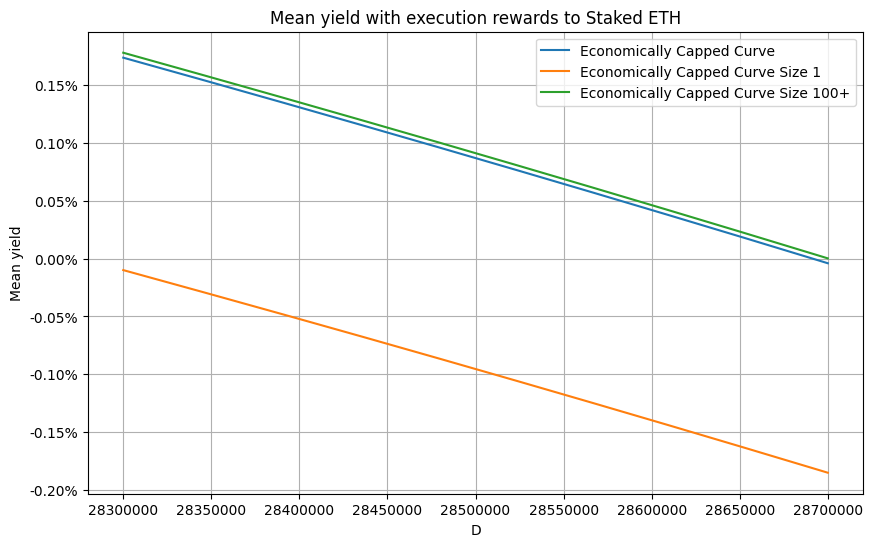

In [32]:
import numpy as np

# Generate D values
D_values = np.arange(28_300_000, 28_700_001, 1_000)

mean_execution = 191178.27657596106
mean_execution_1 = 191178.27657596106 * 0.6314 / 0.8674
mean_execution_5 = 191178.27657596106 * 0.8729 / 0.8674

mean_ret = 3.5442
multiplier_1 = 3.3156 / mean_ret
multiplier_5 = 4.5509 / mean_ret


median_execution = 82587.80682206163

# Calculate Current Curve values
current_curve_values = (2.6 * 64) / np.sqrt(D_values) + mean_execution / D_values
anders_curve_values_1 = (2.6 * 64) * multiplier_1 / (np.sqrt(D_values) * (1 + D_values * 2**(-25))) + mean_execution_1 / D_values
anders_curve_values_5 = (2.6 * 64) * multiplier_5 / (np.sqrt(D_values) * (1 + D_values * 2**(-25))) + mean_execution_5 / D_values
anders_curve_values = (2.6 * 64) / (np.sqrt(D_values) * (1 + D_values * 2**(-25))) + mean_execution / D_values


anders_graduated_curve_values = (2.6 * 64) / (np.sqrt(D_values) * (1 + D_values * 2**(-26))) + mean_execution / D_values
anders_curve_values_1 = (2.6 * 64) * multiplier_1 / (np.sqrt(D_values) * (1 + D_values * 2**(-26))) + mean_execution_1 / D_values
anders_curve_values_5 = (2.6 * 64) * multiplier_5 / (np.sqrt(D_values) * (1 + D_values * 2**(-26))) + mean_execution_5 / D_values

buterin_cap_curve_values = (2.6 * 64) * (1 / np.sqrt(D_values) - 0.5 / (np.sqrt(2**25 - D_values))) + mean_execution / D_values
anders_curve_values_1 = (2.6 * 64) *  (1 / np.sqrt(D_values) - 0.5 / (np.sqrt(2**25 - D_values))) + mean_execution_1 / D_values
anders_curve_values_5 = (2.6 * 64) * (1 / np.sqrt(D_values) - 0.5 / (np.sqrt(2**25 - D_values))) + mean_execution_5 / D_values

comparion = ((2.6 * 64) * multiplier_5 / (np.sqrt(D_values) * (1 + D_values * 2**(-25))) + mean_execution_5 / D_values) / ((2.6 * 64) * multiplier_1 / (np.sqrt(D_values) * (1 + D_values * 2**(-25))) + mean_execution_1 / D_values)

# Create DataFrame
curves = pd.DataFrame({
    'D': D_values,
    #'Current Curve': current_curve_values,
    'Economically Capped Curve': buterin_cap_curve_values,
    'Economically Capped Curve Size 1': anders_curve_values_1,
    'Economically Capped Curve Size 100+': anders_curve_values_5,
    #'comparion': comparion,
    #'Graduated Reduction Curve': anders_graduated_curve_values,
    #'Economically Capped Curve': buterin_cap_curve_values,
    #'Anders Dark Green': anders_dark_green,
    #'Anders Orange': anders_orange,
    #'Anders Pink': anders_pink,
    #'Anders Dark Purple': anders_dark_purple,
    #'Anders Dark Purple Dash': anders_dark_purple_dash
})

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
from matplotlib.ticker import FuncFormatter


plt.figure(figsize=(10, 6))

# Loop through each column (except 'D') and plot against 'D'
for column in curves.columns:
    if column != 'D':
        plt.plot(curves['D'], curves[column], label=column)

plt.title('Mean yield with execution rewards to Staked ETH')
plt.xlabel('D')
plt.ylabel('Mean yield')

plt.legend()

plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x)}'))
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y*100:.2f}%'))

plt.grid(True)
plt.show()
